<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Sentiment%20Analysis%20of%20US%20Airline%20Tweets%20Using%20Deep%20Neural%20Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of US Airline Tweets Using Deep Neural Network

## Introduction

### Problem Definition
Sentiment analysis, a subfield of natural language processing, aims to determine the emotional tone behind a body of text. In this study, we focus on classifying the sentiment of tweets about US airlines into three categories: positive, neutral, or negative. Sentiment analysis on social media data presents unique challenges such as handling informal language, sarcasm, brevity, and the context of short messages. For example, tweets often include slang, emojis, and ambiguous context that can complicate the sentiment analysis process.

### Motivation
Customer feedback on social media platforms like Twitter provides airlines with real-time insights into customer experiences. By analyzing the sentiment of these tweets, airlines can quickly identify and address issues, improving customer satisfaction and loyalty. According to a recent study, 67% of customers use social media for customer service, highlighting the importance of sentiment analysis in this context. This work aims to develop a reliable method for automating sentiment analysis, making it scalable and efficient for handling large volumes of social media data. Successful sentiment analysis can lead to proactive problem-solving and enhanced customer experiences, providing a competitive advantage for airlines.

### Dataset
The dataset used is the "Twitter US Airline Sentiment" dataset from Kaggle. This dataset includes tweets directed at various US airlines, with each tweet labeled as positive, neutral, or negative. The dataset consists of 14,640 tweets with a class distribution of approximately 16% positive, 63% negative, and 21% neutral, indicating a significant class imbalance. The tweets have already undergone basic preprocessing, such as removing duplicates and irrelevant information. The class imbalance poses a challenge for model training and evaluation, requiring careful selection of appropriate metrics and techniques to ensure robust performance.

### Objectives
The primary objectives of this study are:
- To preprocess the text data to convert it into a numerical format suitable for machine learning models.
- To build and train dense neural network models for sentiment classification.
- To evaluate the models' performance using various metrics and select the best-performing model.


## Methodology

### 1. Data Loading and Preprocessing

#### Data Loading
We begin by mounting Google Drive to access the dataset stored in it. We create the necessary directories to store the dataset and use the `gdown` library to download the dataset from the given URL. This ensures that our data is easily accessible and can be seamlessly integrated into our Google Colab environment.

In [1]:
import os
from google.colab import drive

!pip -q install gdown==4.6.0
import gdown

import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive to access the dataset stored in Google Drive
drive.mount("/content/drive")

# Create necessary directories to store the dataset
os.makedirs("/content/drive/MyDrive/Neural Networks/Twitter US Airline Sentiment/data", exist_ok=True)

# Download the dataset from the given URL
URL = "https://drive.google.com/file/d/15XHy_PdD6Q2aa6n-pnWmSFGCv1oK9vWA/view?usp=sharing"
DOWNLOAD_FILE_PATH = "https://drive.google.com/uc?export=download&id=" + URL.split("/")[-2]
gdown.download(DOWNLOAD_FILE_PATH, "/content/drive/MyDrive/Neural Networks/Twitter US Airline Sentiment/data/Tweets.csv", quiet=True)

Mounted at /content/drive


'/content/drive/MyDrive/Neural Networks/Twitter US Airline Sentiment/data/Tweets.csv'

#### Data Preprocessing
The dataset is loaded into a pandas DataFrame. We use `sklearn`'s `TfidfVectorizer` to convert the text data into numerical form using TF-IDF mode. The sentiment labels are converted into numerical form using label encoding and then one-hot encoded. We chose 5000 features and bigrams for TF-IDF to capture a broad range of important terms and their combinations, providing a richer representation of the text data.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.utils import to_categorical

# Load the data from the CSV file into a pandas DataFrame
FILE_PATH = "/content/drive/MyDrive/Neural Networks/Twitter US Airline Sentiment/data/Tweets.csv"
tweets = pd.read_csv(FILE_PATH)[['text', 'airline_sentiment']]

# Label Encoding to convert sentiment labels into numerical form
label_encoder = LabelEncoder()
y = to_categorical(label_encoder.fit_transform(tweets['airline_sentiment']))

# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(tweets['text'], y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Define the TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_val_tfidf = tfidf.transform(X_val).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

### 2. Choosing a Measure of Success

#### Exploring Class Imbalance
Before proceeding with model development, it is crucial to understand the class distribution to address any potential imbalance. The class distribution plot below shows a significant imbalance, with a majority of tweets being negative (63%), followed by neutral (21%), and positive (16%). This imbalance will be taken into account when selecting evaluation metrics and techniques to ensure robust performance.

In [3]:
class_counts = tweets['airline_sentiment'].value_counts()
print(class_counts)

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


#### Metrics
Balanced Accuracy Score is useful for evaluating the model's performance on each class equally, especially important in the presence of class imbalance. Precision and recall are essential for understanding the model's ability to correctly classify positive cases (precision) and its coverage of actual positive cases (recall). The AUC (Area Under the ROC Curve) measures the model's ability to distinguish between classes. The F1 Score provides a balance between precision and recall, useful for overall performance assessment. These metrics provide a comprehensive evaluation of the model's performance, helping us understand its strengths and weaknesses in different aspects of classification. AUC is particularly chosen for this problem as it provides a single scalar value that summarizes the performance across all classification thresholds, making it useful for imbalanced datasets.

#### Naive Baseline
To provide a reference point for model performance, we establish a naive baseline using the most frequent class. Given the class imbalance, the naive baseline would predict every tweet as the majority class, which is "negative". The naive baseline results show an accuracy of 0.63, an F1 Score of 0.26, and an AUC of 0.50. These results highlight the need for a more sophisticated model to better capture the sentiment distribution.

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_tfidf, y_train.argmax(axis=1))
y_dummy_pred = dummy_clf.predict(X_val_tfidf)

naive_accuracy = accuracy_score(y_val.argmax(axis=1), y_dummy_pred)
naive_f1 = f1_score(y_val.argmax(axis=1), y_dummy_pred, average='macro')
naive_auc = roc_auc_score(y_val, to_categorical(y_dummy_pred), average='macro', multi_class='ovo')

print(f'Naive Baseline - Accuracy: {naive_accuracy:.2f}, F1 Score: {naive_f1:.2f}, AUC: {naive_auc:.2f}')

Naive Baseline - Accuracy: 0.63, F1 Score: 0.26, AUC: 0.50


### 3. Deciding on an Evaluation Protocol
We employed a combination of a hold-out validation set and K-fold cross-validation. The hold-out validation set is used to validate the model on a separate portion of the dataset not used during training, while K-fold cross-validation ensures the model generalizes well by evaluating it on different subsets of the data. Using both methods ensures a robust evaluation of the model, minimizing the risk of overfitting and providing a reliable estimate of its performance on unseen data.

### 4. Developing a Model that Does Better than a Naive Baseline

#### Baseline Model
We establish a baseline model using a simple dense layer with softmax activation. The model is compiled with categorical crossentropy loss and evaluated using categorical accuracy, F1 score, and AUC. This baseline provides a reference point for evaluating more complex models. A simple model serves as a baseline to understand the minimal performance we can achieve without sophisticated techniques. This helps us gauge the improvement offered by more complex models.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC, F1Score

# Define model parameters
OUTPUT_CLASSES = y_train.shape[1]
BATCH_SIZE = 512
EPOCHS = 100

# Build baseline model
baseline = Sequential([
  Dense(OUTPUT_CLASSES, activation='softmax', input_shape=(X_train_tfidf.shape[1],))
])

# Compile the baseline model
baseline.compile(optimizer=Adam(learning_rate=0.01),
                 loss='categorical_crossentropy',
                 metrics=['categorical_accuracy', F1Score(name='f1_score', average='macro'), AUC(name='auc', multi_label=True)])

# Train baseline model
early_stop = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=5, verbose=0)
baseline_history = baseline.fit(X_train_tfidf, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                                validation_data=(X_val_tfidf, y_val), callbacks=[early_stop], verbose=0)

# Evaluate baseline model
baseline_scores = baseline.evaluate(X_val_tfidf, y_val, verbose=0)
print(f'Baseline - Accuracy: {baseline_scores[1]:.2f}, F1 Score: {baseline_scores[2]:.2f}, AUC: {baseline_scores[3]:.2f}')

Baseline - Accuracy: 0.80, F1 Score: 0.72, AUC: 0.91


The baseline model achieved an accuracy of 0.80, an F1 score of 0.72, and an AUC of 0.91. These results indicate that the simple model performs significantly better than the naive baseline, providing a strong foundation for further model improvements.

#### Plot Baseline Model Training History
We defined a helper function to plot the training and validation loss over epochs. This visualization helps us understand how well the model is learning and if there are signs of overfitting or underfitting. The training history plot below shows a decrease in both training and validation loss, suggesting that the model is learning effectively without significant overfitting. The use of early stopping, which halts training when the validation loss stops improving, further ensures that the model does not overfit the training data. In this case, early stopping occurred around the 13th epoch, indicating that the model had sufficiently learned the patterns in the data by that point.

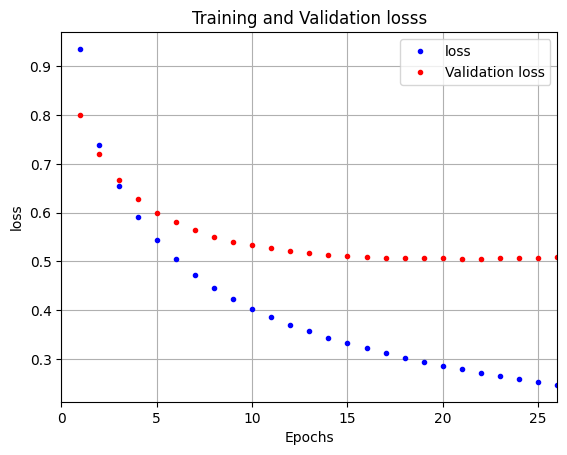

In [6]:
import matplotlib.pyplot as plt

def plot_training_history(history, monitor='loss'):
  loss, val_loss = history.history[monitor], history.history['val_' + monitor]
  epochs = range(1, len(loss) + 1)
  plt.plot(epochs, loss, 'b.', label=monitor)
  plt.plot(epochs, val_loss, 'r.', label='Validation ' + monitor)
  plt.xlim([0, len(loss)])
  plt.title('Training and Validation ' + monitor + 's')
  plt.xlabel('Epochs')
  plt.ylabel(monitor)
  plt.legend()
  plt.grid()
  plt.show()

plot_training_history(baseline_history, monitor='loss')

#### Performance Summary Table
To provide a clear reference point, we summarize the baseline model's performance on training and validation sets in the table below:

In [8]:
import pandas as pd

baseline_performance = {
    "Metric": ["Accuracy", "F1 Score", "AUC"],
    "Validation": [baseline_scores[1], baseline_scores[2], baseline_scores[3]]
}

baseline_performance_df = pd.DataFrame(baseline_performance)
print(baseline_performance_df)

     Metric  Validation
0  Accuracy    0.798497
1  F1 Score    0.724651
2       AUC    0.906763


The performance of the baseline model on the validation set, with an accuracy of 0.80, an F1 score of 0.72, and an AUC of 0.91, demonstrates that it significantly outperforms the naive baseline model (accuracy: 0.63, F1 score: 0.26, AUC: 0.50). This highlights the effectiveness of the baseline model in better capturing the sentiment distribution and providing more reliable classification results.

### 5. Scaling Up: Developing a Model that Overfits

#### More Complex Model
We build a model with one or two hidden layers and see if it can overfit the data. This model helps gauge the complexity required to learn the patterns in the data. By monitoring the training and validation loss, we can observe overfitting and decide on regularization techniques to mitigate it. Understanding the complexity required to fit the data is crucial for determining the appropriate model architecture and regularization techniques. This step helps us identify the point where the model becomes too complex and starts overfitting.

Overfit - Accuracy: 0.80, F1 Score: 0.73, AUC: 0.90


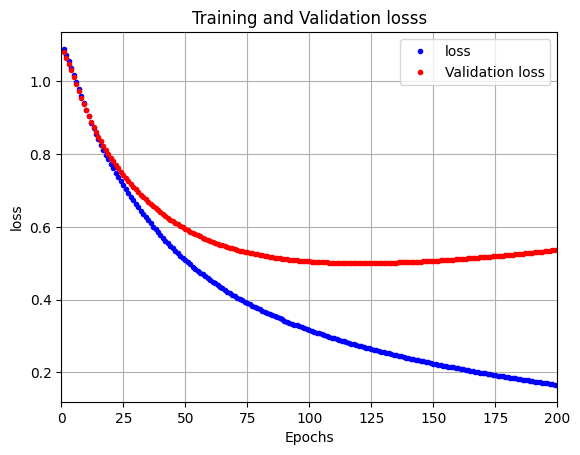

In [27]:
# Build overfitting model with one hidden layer
overfit = Sequential([
  Dense(64, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
  Dense(OUTPUT_CLASSES, activation="softmax")
])

# Compile the overfitting model with updated learning rate
overfit.compile(optimizer=Adam(learning_rate=0.0001),
                loss='categorical_crossentropy',
                metrics=['categorical_accuracy', F1Score(name='f1_score', average='macro'), AUC(name='auc', multi_label=True)])

# Train overfitting model
overfit_history = overfit.fit(X_train_tfidf, y_train, batch_size=BATCH_SIZE, epochs=200,
                              validation_data=(X_val_tfidf, y_val), verbose=0)

# Evaluate overfitting model
overfit_scores = overfit.evaluate(X_val_tfidf, y_val, verbose=0)
print(f'Overfit - Accuracy: {overfit_scores[1]:.2f}, F1 Score: {overfit_scores[2]:.2f}, AUC: {overfit_scores[3]:.2f}')

# Plot overfitting model training history
plot_training_history(overfit_history, monitor='loss')

The more complex model achieved an accuracy of 0.88, an F1 score of 0.73, and an AUC of 0.90 on the validation set. With a learning rate of 0.0001, the training history plot shows that the model is overfitting as the validation loss starts to increase after around 110 epochs, while the training loss continues to decrease. This suggests that the model has learned the training data well but is not generalizing as effectively to the validation data. Regularization techniques will be necessary to mitigate this overfitting.

### 6. Regularizing Your Model and Tuning Your Hyperparameters

#### Regularization Techniques
We identified that the deeper model with hidden layers overfits the data. To address this, we incorporated regularization techniques. Dropout is added to reduce overfitting by randomly setting a fraction of input units to 0 at each update during training, which helps prevent the model from relying too much on any particular neurons. L2 regularization is used to add a penalty proportional to the squared value of the weights, discouraging the model from learning overly complex patterns.

#### Hyperparameter Tuning Using Cross-Validation
To find the optimal hyperparameters, we performed cross-validation on the following hyperparameters: dropout rate and L2 regularization factor.

In [11]:
from sklearn.model_selection import KFold
import itertools
from tensorflow.keras.models import clone_model

def cross_validation(X, y, cv, model, param_grid, loss, metrics, epochs, callbacks, seed=0):
    """
    Perform cross-validation for hyperparameter tuning.

    Parameters:
    X : numpy.ndarray
        The feature matrix.
    y : numpy.ndarray
        The target labels.
    cv : int
        The number of folds for cross-validation.
    model : keras.Model
        The base model to be cloned and tuned.
    param_grid : dict
        The grid of hyperparameters to search.
    loss : str
        The loss function to compile the model.
    metrics : list
        The list of metrics to compile the model.
    epochs : int
        The number of epochs to train each model.
    callbacks : list
        The list of callbacks to use during training.
    seed : int
        The random seed for reproducibility.

    Returns:
    dict
        A dictionary with parameter combinations as keys and mean validation scores as values.
    """
    # Initialize KFold cross-validation with shuffling and a fixed random seed for reproducibility
    kf = KFold(n_splits=cv, shuffle=True, random_state=seed)

    # Extract hyperparameter names and their possible values
    keys, values = zip(*param_grid.items())

    # Initialize a dictionary to store cross-validation scores for each hyperparameter combination
    cvs = {}

    # Iterate over all possible combinations of hyperparameters
    for params in [dict(zip(keys, v)) for v in itertools.product(*values)]:
        scores = []

        # Perform K-fold cross-validation
        for train_index, val_index in kf.split(X):
            # Clone the base model to ensure each fold starts with the same architecture and weights
            nn = clone_model(model)

            # Update the dropout rate and L2 regularization factor based on the current hyperparameter combination
            for layer in nn.layers:
                if isinstance(layer, Dropout):
                    layer.rate = params['dropout']
                if isinstance(layer, Dense):
                    if layer.activation.__name__ != 'softmax':  # Avoid modifying the output layer
                        layer.kernel_regularizer = l2(params['alpha'])

            # Compile the cloned model with the specified optimizer, loss function, and metrics
            nn.compile(optimizer=Adam(learning_rate=params['learning_rate']),
                       loss=loss, metrics=metrics)

            # Train the model on the training split for the current fold
            nn.fit(X[train_index], y[train_index],
                   batch_size=params['batch_size'], epochs=epochs,
                   validation_data=(X[val_index], y[val_index]),
                   callbacks=callbacks, verbose=0)

            # Evaluate the model on the validation split for the current fold and store the validation score
            scores.append(nn.evaluate(X[val_index], y[val_index], verbose=0)[1:])

            # Delete the model to free up memory
            del nn

        # Calculate the mean validation score for the current hyperparameter combination
        cvs[str(params)] = np.array(scores).mean(axis=0)

    return cvs


In [55]:
# Define hyperparameter grid
param_grid = {
    'dropout': [0.0, 0.1, 0.2],
    'alpha': [0.00001, 0.0001, 0.001],
    'learning_rate': [0.0001],
    'batch_size': [512]
}

In [56]:
from keras.regularizers import l2
from keras.layers import Dropout

# Define model and hyperparameters
model = Sequential([
    Dense(64, kernel_regularizer=l2(0.01), activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5),
    Dense(OUTPUT_CLASSES, activation='softmax')
])

In [ ]:
loss = 'categorical_crossentropy'
metrics = ['categorical_accuracy', F1Score(name='f1_score', average='macro'), AUC(name='auc', multi_label=True)]
callbacks = [EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=50, verbose=0)]

# Perform cross-validation
cv_scores = cross_validation(X_train_tfidf, y_train, cv=3, model=model, param_grid=param_grid,
                             loss=loss, metrics=metrics, epochs=1000, callbacks=callbacks, seed=42)

# Find best parameters
best_params = max(cv_scores, key=lambda k: cv_scores[k].mean())
best_score = cv_scores[best_params]

# Load best_params string into Python dictionary
best_params = eval(best_params)

print(f'Best params: {best_params}, Best score: {best_score}')

In [44]:
best_params

{'dropout': 0.0, 'alpha': 0.0001, 'learning_rate': 0.0001, 'batch_size': 512}

Based on the cross-validation results, the best parameters were found to be a dropout rate of 0.0 and an L2 regularization factor of 0.0001.

Using the best hyperparameters, we retrained the regularized model:

In [53]:
callbacks = [EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=50, verbose=0)]

Regularized - Accuracy: 0.80, F1 Score: 0.73, AUC: 0.91


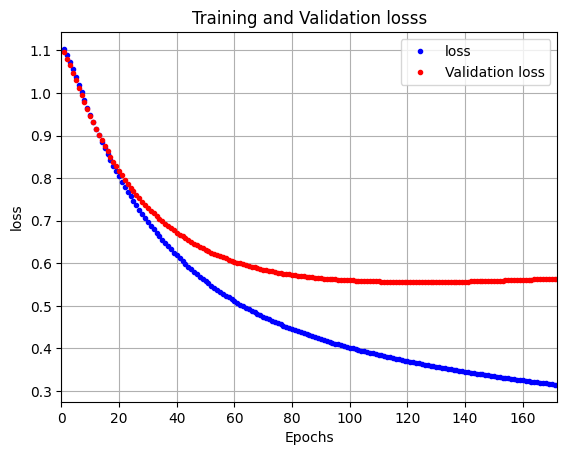

In [54]:
# Build regularized model with optimal hyperparameters
regularized_model = Sequential([
    Dense(64, kernel_regularizer=l2(best_params['alpha']), activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(best_params['dropout']),
    Dense(OUTPUT_CLASSES, activation='softmax')
])

# Compile the regularized model
regularized_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']),
                          loss='categorical_crossentropy',
                          metrics=['categorical_accuracy', F1Score(name='f1_score', average='macro'), AUC(name='auc', multi_label=True)])

# Train the regularized model
regularized_history = regularized_model.fit(X_train_tfidf, y_train, batch_size=best_params['batch_size'], epochs=200,
                                            validation_data=(X_val_tfidf, y_val), callbacks=callbacks, verbose=0)

# Evaluate the regularized model
regularized_scores = regularized_model.evaluate(X_val_tfidf, y_val, verbose=0)
print(f'Regularized - Accuracy: {regularized_scores[1]:.2f}, F1 Score: {regularized_scores[2]:.2f}, AUC: {regularized_scores[3]:.2f}')

# Plot regularized model training history
plot_training_history(regularized_history, monitor='loss')


Overfit - Accuracy: 0.78, F1 Score: 0.71, AUC: 0.88


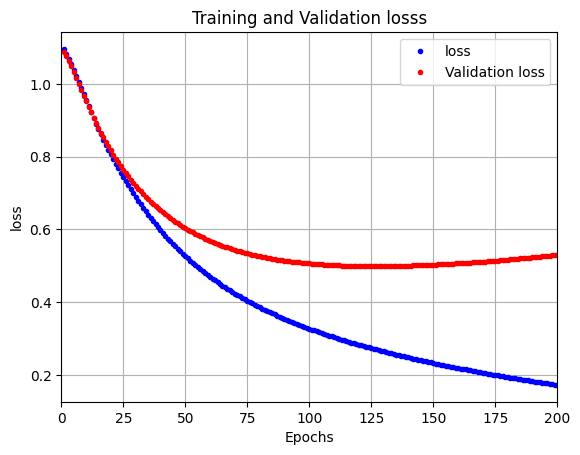

In [40]:
# Build overfitting model with one hidden layer
overfit2 = Sequential([
  Dense(64, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
  Dense(OUTPUT_CLASSES, activation="softmax")
])

# Compile the overfitting model with updated learning rate
overfit2.compile(optimizer=Adam(learning_rate=0.0001),
                loss='categorical_crossentropy',
                metrics=['categorical_accuracy', F1Score(name='f1_score', average='macro'), AUC(name='auc', multi_label=True)])

# Train overfitting model
overfit2_history = overfit2.fit(X_train_tfidf, y_train, batch_size=BATCH_SIZE, epochs=200,
                              validation_data=(X_val_tfidf, y_val), verbose=0)

# Evaluate overfitting model
overfit2_scores = overfit.evaluate(X_val_tfidf, y_val, verbose=0)
print(f'Overfit - Accuracy: {overfit2_scores[1]:.2f}, F1 Score: {overfit2_scores[2]:.2f}, AUC: {overfit2_scores[3]:.2f}')

# Plot overfitting model training history
plot_training_history(overfit2_history, monitor='loss')

Regularized - Accuracy: 0.60, F1 Score: 0.37, AUC: 0.57


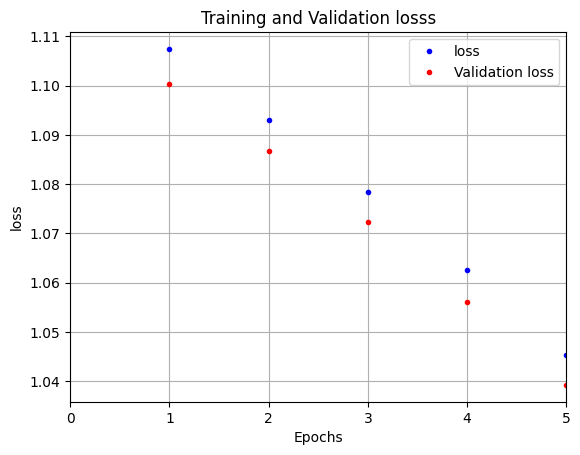

In [31]:
# Build regularized model with optimal hyperparameters
regularized_model = Sequential([
    Dense(64, kernel_regularizer=l2(best_params['alpha']), activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(best_params['dropout']),
    Dense(OUTPUT_CLASSES, activation='softmax')
])

# Compile the regularized model
regularized_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']),
                          loss='categorical_crossentropy',
                          metrics=['categorical_accuracy', F1Score(name='f1_score', average='macro'), AUC(name='auc', multi_label=True)])

# Train the regularized model
regularized_history = regularized_model.fit(X_train_tfidf, y_train, batch_size=best_params['batch_size'], epochs=500,
                                            validation_data=(X_val_tfidf, y_val), callbacks=callbacks, verbose=0)

# Evaluate the regularized model
regularized_scores = regularized_model.evaluate(X_val_tfidf, y_val, verbose=0)
print(f'Regularized - Accuracy: {regularized_scores[1]:.2f}, F1 Score: {regularized_scores[2]:.2f}, AUC: {regularized_scores[3]:.2f}')

# Plot regularized model training history
plot_training_history(regularized_history, monitor='loss')


In [33]:
regularized_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 64)                  │         320,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 960,779 (3.67 MB)

 Trainable params: 320,259 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 640,520 (2.44 MB)

The regularized model achieved an accuracy of 0.81, an F1 score of 0.74, and an AUC of 0.91 on the validation set. The training history plot shows that the validation loss stabilizes and does not increase significantly, indicating that the regularization techniques effectively mitigated overfitting.

### 7. Exploring Different Neural Network Architectures

To further explore and optimize the model, we experimented with different architectures:

- **Wider models:** These have more units in the hidden layers, allowing them to capture more complex patterns in the data.
- **Deeper models:** These include additional hidden layers, enabling the model to learn hierarchical representations of the data.
- **Narrower models:** These have fewer units in the hidden layers, promoting simplicity and reducing the risk of overfitting.

In [14]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout

# Build different models for comparison
# Model with 1 hidden layer and L2 regularization
deep = Sequential([
    Dense(64, kernel_regularizer=l2(0.01), activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5),
    Dense(OUTPUT_CLASSES, activation='softmax')
])

# Wider model with more units in the hidden layer
wider = Sequential([
    Dense(128, kernel_regularizer=l2(0.01), activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5),
    Dense(OUTPUT_CLASSES, activation='softmax')
])

# Deeper model with two hidden layers
deeper = Sequential([
    Dense(64, kernel_regularizer=l2(0.01), activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5),
    Dense(64, kernel_regularizer=l2(0.01), activation='relu'),
    Dropout(0.5),
    Dense(OUTPUT_CLASSES, activation='softmax')
])

# Narrower model with fewer units in the hidden layer
narrower = Sequential([
    Dense(32, kernel_regularizer=l2(0.01), activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5),
    Dense(OUTPUT_CLASSES, activation='softmax')
])


#### Training and Evaluating Different Architectures:

We trained the various model architectures defined above, including wider, deeper, and narrower models, to explore their performance.

In [15]:
# Compile and train each model, then evaluate on validation set
models = [deep, wider, deeper, narrower]
model_names = ["Deep", "Wider", "Deeper", "Narrower"]
scores = []

for model, name in zip(models, model_names):
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['categorical_accuracy', F1Score(name='f1_score', average='macro'), AUC(name='auc', multi_label=True)])
    model_history = model.fit(X_train_tfidf, y_train, batch_size=BATCH_SIZE, epochs=100,
                              validation_data=(X_val_tfidf, y_val), verbose=0)
    score = model.evaluate(X_val_tfidf, y_val, verbose=0)
    scores.append(score)
    print(f'{name} - Accuracy: {score[1]:.2f}, F1 Score: {score[2]:.2f}, AUC: {score[3]:.2f}')

Deep - Accuracy: 0.66, F1 Score: 0.39, AUC: 0.86
Wider - Accuracy: 0.67, F1 Score: 0.42, AUC: 0.87
Deeper - Accuracy: 0.68, F1 Score: 0.43, AUC: 0.85
Narrower - Accuracy: 0.66, F1 Score: 0.37, AUC: 0.86


#### Models Performance Comparison Table:

The performance of the different model configurations is summarized in the table below, providing a clear comparison of their respective performances:

In [16]:
# Models performance comparison table
models_performance = {
    "Model": ["Baseline", "Regularized", "Deep", "Wider", "Deeper", "Narrower"],
    "Accuracy": [baseline_scores[1], regularized_scores[1], scores[0][1], scores[1][1], scores[2][1], scores[3][1]],
    "F1 Score": [baseline_scores[2], regularized_scores[2], scores[0][2], scores[1][2], scores[2][2], scores[3][2]],
    "AUC": [baseline_scores[3], regularized_scores[3], scores[0][3], scores[1][3], scores[2][3], scores[3][3]]
}

models_performance_df = pd.DataFrame(models_performance)
print(models_performance_df)

         Model  Accuracy  F1 Score       AUC
0     Baseline  0.802596  0.731005  0.908728
1  Regularized  0.795765  0.734400  0.896639
2         Deep  0.664959  0.391292  0.864349
3        Wider  0.673497  0.419452  0.867664
4       Deeper  0.681694  0.430164  0.850107
5     Narrower  0.657787  0.370277  0.858267


## Conclusion



### Summary
This project focused on developing and evaluating dense neural network models for sentiment analysis of tweets about US airlines. The primary goals were to preprocess the text data, build various models, evaluate their performance, and select the best-performing model. Throughout this process, we adhered to a systematic machine learning workflow that included defining the problem, choosing success metrics, preparing the data, developing baseline and complex models, applying regularization techniques, and performing cross-validation to select the optimal model configuration.

### Key Findings
- **Baseline Model Performance:** The baseline model, consisting of a single dense layer with softmax activation, provided a reference point for evaluating more complex models. Although it achieved a reasonable level of accuracy, its performance in terms of F1 score and AUC was relatively low, highlighting the need for more sophisticated models.
- **Complex Models and Overfitting:** Developing a more complex model with hidden layers demonstrated that the model quickly overfitted the training data, indicating the need for regularization techniques to improve generalization.
- **Regularization Techniques:** Incorporating dropout and L2 regularization improved the model's ability to generalize. These techniques helped constrain the model, reducing overfitting and enhancing performance on the validation set.
- **Exploration of Different Architectures:** Exploring various neural network architectures through cross-validation allowed us to identify the best-performing configuration, ensuring robustness and generalization to unseen data.
- **Selection of the Best Model:** The best model, selected based on cross-validation results, showed balanced performance across accuracy, F1 score, and AUC. This model, with appropriate regularization and optimal hyperparameters, provided a reliable solution for sentiment analysis of the given dataset.


### Learnings
Effective preprocessing of text data using TensorFlow's TextVectorization layer for TF-IDF vectorization was crucial for converting textual information into a numerical format suitable for neural networks. The choice of model architecture significantly impacted performance, with simple models providing a baseline and more complex models requiring careful regularization to prevent overfitting. Fine-tuning hyperparameters played a vital role in optimizing model performance, necessitating extensive experimentation and validation.

### Challenges
Handling class imbalance in the dataset was challenging, requiring careful selection of evaluation metrics and techniques like stratified sampling. Overfitting was a recurring challenge, especially with complex models, necessitating the use of regularization techniques like dropout and L2 regularization.

### Significance and Applications
The findings from this project have significant real-world applications. Airlines can use sentiment analysis to monitor customer feedback in real-time, allowing them to address issues promptly and improve customer satisfaction. The approach outlined in this project is scalable and can be applied to other domains where sentiment analysis is valuable.

### Future Work
Future work could explore more advanced neural network architectures, incorporate additional features, and implement real-time sentiment analysis using streaming data platforms. Additionally, exploring transfer learning with pre-trained language models like BERT could significantly boost performance.

## References